# ICMS 150 (2 Day experiment summary)

- Closed loop plan: day 1: perform visual (16 orientations, 100 trials) and electrical (3000 patterns, 50 oracles x 20 trials). This notebook is used after output spike sorting and curation to fit stimulus-encoder TCN model and generate stimualtion patterns for each orientation to try on day 2. 


Visual stim duration: 0.5s ON, 0.5s OFF
Velocity(temporal frequency): 3Hz
Width (spatial frequency): 0.05 cycle/degree
After that is 4000 patterns, 3000 samples appear 1 times, 50 oracle samples repeating 20 times


In [ ]:
import sys
sys.path.insert(0, '../patterns_5k')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils import read_pattern_json, preprocess_pattern_stimulations_df, build_pattern_stims_nominal
%load_ext autoreload
%autoreload 2
day1_datadir = "data/icms_150_6_2_26"
day2_datadir = "data/icms_150_6_3_26"
mode = "pca"

all_spikes_day1 = np.load(f"{day1_datadir}/All_Shank_Spk_Vecs.npy", allow_pickle=False) # contains each spike indexed with (sample index, unit index, segment index)
all_spikes_day2 = np.load(f"{day2_datadir}/All_Shank_Spk_Vecs.npy", allow_pickle=False) # contains each spike indexed with (sample index, unit index, segment index)

spikes_df_day1 = pd.DataFrame(all_spikes_day1)  # columns auto-named from dtype fields
spikes_df_day1.rename(columns={'sample_index': 'timestamp', 'unit_index': 'neuron_id'}, inplace=True)
spikes_df_day1.drop(columns=['segment_index'], inplace=True)

spikes_df_day2 = pd.DataFrame(all_spikes_day2)  # columns auto-named from dtype fields
spikes_df_day2.rename(columns={'sample_index': 'timestamp', 'unit_index': 'neuron_id'}, inplace=True)
spikes_df_day2.drop(columns=['segment_index'], inplace=True)

pattern_df_day1, min_pattern_timestamp_day1 = preprocess_pattern_stimulations_df(read_pattern_json(f"{day1_datadir}/Combined_Pattern_Registrations.pkl"), align_to_stim=True)
pattern_df_day2, min_pattern_timestamp_day2 = preprocess_pattern_stimulations_df(read_pattern_json(f"{day2_datadir}/Combined_Pattern_Registrations.pkl"), align_to_stim=True)

visual_stim_times_day1= np.load(f"{day1_datadir}/VStim_Onset_TS.npy") * 30 # 1600
visual_stim_times_day2= np.load(f"{day2_datadir}/VStim_Onset_TS.npy") * 30 # 1600
visual_stim_labels_day1 = np.load(f"{day1_datadir}/VStim_Labels.npy") # 1600 
visual_stim_labels_day2 = np.load(f"{day2_datadir}/VStim_Labels.npy") # 1600

visual_orientation_degs1 = np.sort(np.unique(visual_stim_labels_day1))
visual_orientation_degs2 = np.sort(np.unique(visual_stim_labels_day2))
visual_trial_df1 = pd.DataFrame({
    'timestamp': visual_stim_times_day1,
    'orientation': visual_stim_labels_day1
})
visual_trial_df2 = pd.DataFrame({
    'timestamp': visual_stim_times_day2,
    'orientation': visual_stim_labels_day2
})
min_visual_timestamp_1 = visual_trial_df1['timestamp'].min()
max_visual_timestamp_1 = visual_trial_df1['timestamp'].max()
min_visual_timestamp_2 = visual_trial_df2['timestamp'].min()
max_visual_timestamp_2 = visual_trial_df2['timestamp'].max()

visual_spikes_1 = spikes_df_day1[(spikes_df_day1['timestamp'] >= min_visual_timestamp_1) & (spikes_df_day1['timestamp'] <= max_visual_timestamp_1)].copy()
visual_spikes_2 = spikes_df_day2[(spikes_df_day2['timestamp'] >= min_visual_timestamp_2) & (spikes_df_day2['timestamp'] <= max_visual_timestamp_2)].copy()

## Visual Tuning over 2 Days 

In [3]:

# --- Timing constants -------------------------------------------------
# Spike timestamps are in *samples* at SAMPLE_RATE Hz. The visual stimulus
# was shown for STIM_MS ms, so we bin the full stim window (no data is
# thrown away). The window is chopped into bins of BIN_MS ms.
SAMPLE_RATE    = 30_000                       # Hz
STIM_MS        = 500                          # stimulus duration (ms)
BIN_MS         = 10                           # PSTH bin width (ms)

SAMPLES_PER_MS = SAMPLE_RATE // 1000          # 30 samples / ms
WINDOW_LEN     = STIM_MS * SAMPLES_PER_MS     # 500 ms -> 15000 samples
BIN_SAMPLES    = BIN_MS  * SAMPLES_PER_MS     # 50 ms  -> 1500 samples
N_BINS         = WINDOW_LEN // BIN_SAMPLES    # STIM_MS / BIN_MS
assert WINDOW_LEN % BIN_SAMPLES == 0, "BIN_MS must evenly divide STIM_MS"

N_VIS_TRIALS = 100

def make_sum_responses(visual_spikes, visual_trial_df, visual_orientation_degs):
    all_neuron_ids = np.sort(visual_spikes['neuron_id'].unique())
    n_neurons = len(all_neuron_ids)
    neuron_to_idx = {n: i for i, n in enumerate(all_neuron_ids)}

    sum_responses = []
    trial_labels = []
    for orientation in visual_orientation_degs:
        sum_response = np.zeros((n_neurons, N_BINS))
        for trial in range(N_VIS_TRIALS):
            trial_time = visual_trial_df[visual_trial_df['orientation'] == orientation].iloc[trial]['timestamp']
            trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= trial_time) &
                                        (visual_spikes['timestamp'] <  trial_time + WINDOW_LEN)]
            if trial_spikes.empty:
                continue
            bin_edges = trial_time + np.arange(N_BINS + 1) * BIN_SAMPLES  # N_BINS+1 edges across STIM_MS

            for neuron_id in trial_spikes['neuron_id'].unique():
                idx = neuron_to_idx[neuron_id]
                counts, _ = np.histogram(
                    trial_spikes[trial_spikes['neuron_id'] == neuron_id]['timestamp'],
                    bins=bin_edges,
                )
                sum_response[idx] += counts
        sum_response /= N_VIS_TRIALS  # average over trials 
        sum_responses.append(sum_response) 
    sum_responses = np.array(sum_responses)
    return sum_responses  # (n_orientations, n_neurons, N_BINS)
sum_responses_1 = make_sum_responses(visual_spikes_1, visual_trial_df1, visual_orientation_degs1)
sum_responses_2 = make_sum_responses(visual_spikes_2, visual_trial_df2, visual_orientation_degs2)
print(f"Window: {STIM_MS} ms = {WINDOW_LEN} samples at {SAMPLE_RATE} Hz")
print(f"Bins:   {N_BINS} x {BIN_MS} ms ({BIN_SAMPLES} samples each)")
print(f"sum_responses1 shape (orient, neuron, time_bin): {sum_responses_1.shape}")
print(f"sum_responses2 shape (orient, neuron, time_bin): {sum_responses_2.shape}")


Window: 500 ms = 15000 samples at 30000 Hz
Bins:   50 x 10 ms (300 samples each)
sum_responses1 shape (orient, neuron, time_bin): (16, 63, 50)
sum_responses2 shape (orient, neuron, time_bin): (16, 55, 50)


In [ ]:
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Compute 3-axis projection: [CIS, PC1, PC2]
def make_ring(sum_responses, visual_orientation_degs, visual_trial_df, visual_spikes, mode="pca", proj=None):
    n_neurons = sum_responses.shape[1]
    all_neuron_ids = np.sort(visual_spikes['neuron_id'].unique())
    neuron_to_idx = {n: i for i, n in enumerate(all_neuron_ids)}
    X = sum_responses.sum(axis=-1)             # (n_orientations, n_neurons)  -- per-orientation averages
    mean_vec = X.mean(axis=0, keepdims=True)


    # 1. Extract raw trial counts and labels to fit LDA
    vis_window_samples = (600 * SAMPLE_RATE) // 1000
    trial_raw_counts = []
    trial_labels = []

    for orientation in visual_orientation_degs:
        trial_times = visual_trial_df[visual_trial_df['orientation'] == orientation]['timestamp'].values[:N_VIS_TRIALS]
        for t_time in trial_times:
            trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= t_time) &
                                        (visual_spikes['timestamp'] <  t_time + vis_window_samples)]
            x_trial = np.zeros(n_neurons)
            if not trial_spikes.empty:
                counts = trial_spikes.groupby('neuron_id').size()
                for nid, c in counts.items():
                    if nid in neuron_to_idx:
                        x_trial[neuron_to_idx[nid]] = c
            trial_raw_counts.append(x_trial)
            trial_labels.append(orientation)

    trial_raw_counts = np.array(trial_raw_counts)
    trial_labels = np.array(trial_labels)

    # 2. Fit LDA to visual trials
    # LDA requires categorical labels, so we map orientations to strings
    lda_labels = trial_labels.astype(str)

    # (Using n_components=2 to match PC plot)
    lda = LDA(n_components=2)
    lda.fit(trial_raw_counts, lda_labels)
    if proj is None: 
        if mode == "pca":
            pca3 = PCA(n_components=2)
            pca3.fit(X)
            proj, _ = np.linalg.qr(np.array([
                mean_vec[0],
                pca3.components_[0],
                pca3.components_[1],
            ]).T)        
            print ("PCA explained variance ratio:", pca3.explained_variance_ratio_)
        elif mode == "lda":
            proj, _ = np.linalg.qr(np.array([
                mean_vec[0],
                lda.scalings_[:, 0],
                lda.scalings_[:, 1],
            ]).T)
            print ("LDA explained variance ratio:", lda.explained_variance_ratio_)
        else:
            raise ValueError(f"Unknown mode: {mode}")
    

    coords = X @ proj                           # (n_orientations, 3)  -- averaged points

    # ---- Per-trial points: spike counts per (orientation, trial) summed over time bins ----
    trial_coords = []     # (n_orient * n_trials, 3)
    trial_doubled = []    # color matches its orientation
    for o_idx, orientation in enumerate(visual_orientation_degs):
        trial_times = visual_trial_df[visual_trial_df['orientation'] == orientation]['timestamp'].values[:N_VIS_TRIALS]
        for t_time in trial_times:
            trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= t_time) &
                                        (visual_spikes['timestamp'] <  t_time + WINDOW_LEN)]
            x_trial = np.zeros(n_neurons)
            if not trial_spikes.empty:
                counts = trial_spikes.groupby('neuron_id').size()
                for nid, c in counts.items():
                    if nid in neuron_to_idx:
                        x_trial[neuron_to_idx[nid]] = c
            trial_coords.append(x_trial @ proj)
            trial_doubled.append((int(orientation) * 2) % 360)
    trial_coords = np.array(trial_coords)
    trial_doubled = np.array(trial_doubled)

    doubled = (np.array(visual_orientation_degs) * 2) % 360

    fig = go.Figure()

    # Per-trial scatter (low alpha)
    fig.add_trace(go.Scatter3d(
        x=trial_coords[:, 0], y=trial_coords[:, 1], z=trial_coords[:, 2],
        mode='markers',
        marker=dict(size=3, color=trial_doubled, colorscale='HSV',
                    cmin=0, cmax=360, opacity=0.05,
                    line=dict(width=0)),
        name='Individual trials',
        hovertemplate='trial<extra></extra>',
        showlegend=True,
    ))

    # Orientation-average scatter (full opacity, on top)
    fig.add_trace(go.Scatter3d(
        x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
        mode='markers+text',
        marker=dict(size=8, color=doubled, colorscale='HSV',
                    cmin=0, cmax=360,
                    colorbar=dict(
                        title='Orientation (°)',
                        tickvals=np.arange(0, 361, 72),
                        ticktext=[f'{int(v/2)}°' for v in np.arange(0, 361, 72)],
                    ),
                    line=dict(color='black', width=1)),
        text=[f'{int(o)}°' for o in visual_orientation_degs],
        textposition='top center',
        name='Orientation average',
    ))
    if mode == "pca":
        fig.update_layout(title='Average Neural Responses to Visual Stimuli (PCA Projection)')
        fig.update_layout(
        title='Average Neural Responses to Visual Stimuli',
        scene=dict(xaxis_title='CIS', yaxis_title='PC1', zaxis_title='PC2',
                aspectmode='data'),
        width=800, height=700,
    )
    elif mode == "lda":
        fig.update_layout(title='Average Neural Responses to Visual Stimuli (LDA Projection)')
        fig.update_layout(
        title='Average Neural Responses to Visual Stimuli',
        scene=dict(xaxis_title='CIS', yaxis_title='LDA1', zaxis_title='LDA2',
                aspectmode='data'),
        width=800, height=700,  
    )
    fig.show()
    return proj
day1_proj = make_ring(sum_responses_1, visual_orientation_degs1, visual_trial_df1, visual_spikes_1, mode="pca")


In [ ]:
day2_proj = make_ring(sum_responses_2, visual_orientation_degs2, visual_trial_df2, visual_spikes_2, mode="pca", proj=day1_proj)


## Stim Responses, Day 2 Only

In [2]:
target_mapping = pd.read_csv('data/icms_150_4_4_26/merged_pattern_xref.csv')
target_mapping

,pattern_name,source_file,source_budget,source_pattern_name,ori_idx,target_orientation_deg,start_timing_index,n_trials,steps_str
0,502,generated_pattern_registration_4budget_600ms.pkl,4,502,2,45.0,1,1,[0]ch57:dm2;ch74:dm2;ch88:dm-1;ch113:dm-1 | [1...
1,5011,generated_pattern_registration_4budget_600ms.pkl,4,5011,11,247.5,2,1,[0]ch57:dm2;ch74:dm2;ch88:dm-1;ch113:dm-1 | [1...
2,503,generated_pattern_registration_4budget_600ms.pkl,4,503,3,67.5,3,1,[0]ch57:dm2;ch74:dm2;ch88:dm-1;ch113:dm-1 | [1...
3,5010,generated_pattern_registration_4budget_600ms.pkl,4,5010,10,225.0,4,1,[0]ch57:dm2;ch74:dm2;ch88:dm-1;ch113:dm-1 | [1...
4,500,generated_pattern_registration_4budget_600ms.pkl,4,500,0,0.0,5,1,[0]ch57:dm2;ch74:dm2;ch88:dm-1;ch113:dm-1 | [1...
5,504,generated_pattern_registration_4budget_600ms.pkl,4,504,4,90.0,6,1,[0]ch57:dm2;ch74:dm2;ch91:dm-1;ch113:dm2 | [1]...
6,507,generated_pattern_registration_4budget_600ms.pkl,4,507,7,157.5,7,1,[0]ch57:dm2;ch74:dm2;ch88:dm-1;ch113:dm-1 | [1...
7,505,generated_pattern_registration_4budget_600ms.pkl,4,505,5,112.5,8,1,[0]ch57:dm2;ch78:dm0;ch113:dm2;ch127:dm-1 | [1...
8,5014,generated_pattern_registration_4budget_600ms.pkl,4,5014,14,315.0,9,1,[0]ch57:dm2;ch74:dm2;ch88:dm-1;ch113:dm-1 | [1...
9,5012,generated_pattern_registration_4budget_600ms.pkl,4,5012,12,270.0,10,1,[0]ch57:dm2;ch74:dm2;ch91:dm-1;ch113:dm2 | [1]...


In [4]:
sum_responses_2.shape

(16, 55, 50)

In [ ]:
# ============================================================
# Delivered stim trajectories in the day-2 visual target space.
#
# For every (budget, projection) combination we:
#   1. Build a mode-switchable 2-D projection [axis1, axis2] from the day-2
#      visual responses (PCA on per-orientation averages, or LDA on per-trial
#      counts) -- the same basis the day-2 target ring lives in.
#   2. For each of the 16 target orientations, take its delivered stim pattern
#      on day 2 (pattern_name from the xref), bin the post-stim population
#      response in 10 ms bins, AVERAGE across that pattern's ~20 deliveries,
#      project each time bin into the 2-D space, and draw the resulting
#      trajectory (start = open circle, end = filled marker).
#   3. Overlay the day-2 visual target ring so we can see whether the delivered
#      trajectory lands near its intended orientation.
#
# One PNG per orientation, saved under
#   data/icms_150_6_3_26/traj/budget_{B}_mode_{M}/
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

VIS_ORIENT_TIME = 600                       # ms window used to define targets
N_TRAJ_BINS     = VIS_ORIENT_TIME // BIN_MS  # 60 x 10 ms bins post-stim
TRAJ_WIN_LEN    = VIS_ORIENT_TIME * SAMPLES_PER_MS

xref = pd.read_csv('data/icms_150_6_2_26/generated_patterns_day2_6_3_26.csv')
xref['pattern_name'] = xref['pattern_name'].astype(int)

# day-2 spike neuron indexing (matches make_sum_responses' ordering)
d2_neuron_ids   = np.sort(visual_spikes_2['neuron_id'].unique())
d2_neuron_to_idx = {n: i for i, n in enumerate(d2_neuron_ids)}
d2_n_neurons     = len(d2_neuron_ids)

# Per-pattern delivery onsets on day 2 (aligned to first stim by preprocess_*).
deliveries = (pattern_df_day2[['pattern_name', 'pattern_timing_index',
                               'pattern_flag_start_timestamp']]
              .drop_duplicates())


def build_proj(mode):
    """2-D day-2 visual projection [axis1, axis2]; drops the CIS/mean axis."""
    X = sum_responses_2.sum(axis=-1)  * VIS_ORIENT_TIME / STIM_MS                    # scale target 
    mean_vec = X.mean(axis=0, keepdims=True)
    if mode == "pca":
        pca = PCA(n_components=2).fit(X)
        basis = np.array([mean_vec[0], pca.components_[0], pca.components_[1]]).T
    elif mode == "lda":
        # per-trial counts over VIS_ORIENT_TIME for LDA fit
        vis_win = (VIS_ORIENT_TIME * SAMPLE_RATE) // 1000
        rows, labels = [], []
        for orientation in visual_orientation_degs2:
            for t0 in visual_trial_df2[visual_trial_df2['orientation'] == orientation]['timestamp'].values[:N_VIS_TRIALS]:
                ts = visual_spikes_2[(visual_spikes_2['timestamp'] >= t0) &
                                     (visual_spikes_2['timestamp'] <  t0 + vis_win)]
                v = np.zeros(d2_n_neurons)
                if not ts.empty:
                    for nid, c in ts.groupby('neuron_id').size().items():
                        if nid in d2_neuron_to_idx:
                            v[d2_neuron_to_idx[nid]] = c
                rows.append(v); labels.append(str(orientation))
        lda = LDA(n_components=2).fit(np.array(rows), np.array(labels))
        basis = np.array([mean_vec[0], lda.scalings_[:, 0], lda.scalings_[:, 1]]).T
    else:
        raise ValueError(mode)
    proj, _ = np.linalg.qr(basis)                        # (n_neurons, 3)
    target_coords = X @ proj                             # (n_orient, 3)
    return proj, target_coords


def mean_trajectory(pattern_name, proj):
    """Mean time-binned post-stim response trajectory for one pattern,
    averaged across all its day-2 deliveries, projected to [axis1, axis2]."""
    onsets = deliveries[deliveries['pattern_name'] == pattern_name]['pattern_flag_start_timestamp'].values
    if len(onsets) == 0:
        return None, 0
    binned = np.zeros((N_TRAJ_BINS, d2_n_neurons))       # accumulate counts
    used = 0
    for t0 in onsets:
        seg = spikes_df_day2[(spikes_df_day2['timestamp'] >= t0) &
                             (spikes_df_day2['timestamp'] <  t0 + TRAJ_WIN_LEN)]
        if seg.empty:
            continue
        bin_edges = t0 + np.arange(N_TRAJ_BINS + 1) * BIN_SAMPLES
        for nid, grp in seg.groupby('neuron_id'):
            if nid in d2_neuron_to_idx:
                counts, _ = np.histogram(grp['timestamp'], bins=bin_edges)
                binned[:, d2_neuron_to_idx[nid]] += counts
        used += 1
    if used == 0:
        return None, 0
    binned /= used
    # cumulative population state over time (so the path traces accumulating
    # response, comparable to the summed-window targets), then project.
    cumulative = np.cumsum(binned, axis=0)               # (N_TRAJ_BINS, n_neurons)
    traj = cumulative @ proj                             # (N_TRAJ_BINS, 3)
    return traj, used


for (budget, mode), grp in xref.groupby(['source_budget', 'decomp_method']):
    proj, target_coords = build_proj(mode)
    out_dir = f'data/icms_150_6_3_26/traj/budget_{budget}_mode_{mode}'
    os.makedirs(out_dir, exist_ok=True)

    doubled_all = (np.array(visual_orientation_degs2) * 2) % 360

    for _, row in grp.sort_values('target_orientation_deg').iterrows():
        pname   = int(row['pattern_name'])
        ori_deg = float(row['target_orientation_deg'])
        o_idx   = int(row['ori_idx'])
        traj, n_used = mean_trajectory(pname, proj)
        if traj is None:
            print(f'[skip] budget={budget} mode={mode} ori={ori_deg}: no deliveries for {pname}')
            continue

        fig, ax = plt.subplots(figsize=(7.5, 7))
        
        # day-2 visual target ring (axes 1 & 2 of the projection)
        ax.scatter(target_coords[:, 1], target_coords[:, 2],
                   c=doubled_all, cmap='hsv', vmin=0, vmax=360,
                   s=90, edgecolors='black', linewidths=1.0, zorder=3)
        for k, o in enumerate(visual_orientation_degs2):
            ax.annotate(f'{int(o)}°', (target_coords[k, 1], target_coords[k, 2]),
                        textcoords='offset points', xytext=(4, 4), fontsize=7, zorder=4)

        # delivered trajectory, colored by time (dark = start -> bright = end)
        ax.plot(traj[:, 1], traj[:, 2], '-', color='0.4', lw=1.0, zorder=5, alpha=0.6)
        ax.scatter(traj[:, 1], traj[:, 2], c=np.arange(N_TRAJ_BINS),
                   cmap='viridis', s=14, zorder=6)
        ax.scatter(traj[0, 1], traj[0, 2], facecolors='none', edgecolors='k',
                   s=120, linewidths=1.5, zorder=7, label='start (0 ms)')
        ax.scatter(traj[-1, 1], traj[-1, 2], marker='*', s=260, color='red',
                   edgecolors='k', linewidths=0.8, zorder=8,
                   label=f'end ({VIS_ORIENT_TIME} ms)')

        # highlight the intended target for this orientation
        ax.scatter(target_coords[o_idx, 1], target_coords[o_idx, 2],
                   facecolors='none', edgecolors='red', s=240, linewidths=2.0,
                   zorder=9, label=f'intended target ({int(ori_deg)}°)')

        ax.set_xlabel('PC1' if mode == 'pca' else 'LD1')
        ax.set_ylabel('PC2' if mode == 'pca' else 'LD2')
        ax.set_title(f'Delivered trajectory — budget={budget}, mode={mode.upper()}\n'
                     f'pattern {pname}  target {int(ori_deg)}°  ({n_used} deliveries)')
        ax.legend(loc='best', fontsize=8)
        ax.set_aspect('equal', adjustable='datalim')
        plt.tight_layout()

        fname = f'{out_dir}/ori_{int(ori_deg):03d}_pattern_{pname}.png'
        fig.savefig(fname, dpi=140)
        plt.close(fig)

    print(f'[done] budget={budget} mode={mode}: wrote {len(grp)} trajectories -> {out_dir}/')

print('\nAll trajectory figures saved under data/icms_150_6_3_26/traj/')


[done] budget=4 mode=lda: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_4_mode_lda/
[done] budget=4 mode=pca: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_4_mode_pca/
[done] budget=6 mode=lda: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_6_mode_lda/
[done] budget=6 mode=pca: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_6_mode_pca/
[done] budget=8 mode=lda: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_8_mode_lda/
[done] budget=8 mode=pca: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_8_mode_pca/
[done] budget=10 mode=lda: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_10_mode_lda/
[done] budget=10 mode=pca: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_10_mode_pca/

All trajectory figures saved under data/icms_150_6_3_26/traj/


In [17]:
# ============================================================
# Endpoint summary: all 16 orientation stim endpoints vs targets on one plot.
#
# For each (budget, mode) combo, one figure showing:
#   - Circles  : day-2 visual target ring (same as above)
#   - Squares  : the cumulative-response endpoint of each delivered pattern
#                (mean across deliveries, final time bin = 600 ms)
# Both are color-coded with the same HSV doubled-angle colormap so matching
# orientation gets matching color. Lines connect each endpoint to its target.
#
# Controls (set below):
#   ALL_TRIALS  = False  -> show mean-trajectory endpoint only
#   ALL_TRIALS  = True   -> show every individual delivery endpoint (scatter)
#   PLOTMODE    = '2d'   -> PC1/PC2 plane
#   PLOTMODE    = '3d'   -> CIS + PC1/PC2
#
# Saved to: data/icms_150_6_3_26/traj{PLOTMODE}_endpoints[_all_trials]/
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# ---- controls ---------------------------------------------------
PLOTMODE   = '2d'    # '2d' or '3d'
ALL_TRIALS = False   # True: show every delivery; False: show trial-mean only
# -----------------------------------------------------------------

VIS_ORIENT_TIME = 600
N_TRAJ_BINS     = VIS_ORIENT_TIME // BIN_MS
TRAJ_WIN_LEN    = VIS_ORIENT_TIME * SAMPLES_PER_MS

xref = pd.read_csv('data/icms_150_6_2_26/generated_patterns_day2_6_3_26.csv')
xref['pattern_name'] = xref['pattern_name'].astype(int)

d2_neuron_ids    = np.sort(visual_spikes_2['neuron_id'].unique())
d2_neuron_to_idx = {n: i for i, n in enumerate(d2_neuron_ids)}
d2_n_neurons     = len(d2_neuron_ids)

deliveries = (pattern_df_day2[['pattern_name', 'pattern_timing_index',
                               'pattern_flag_start_timestamp']]
              .drop_duplicates())

def _build_proj(mode):
    X = sum_responses_2.sum(axis=-1) * VIS_ORIENT_TIME / STIM_MS
    mean_vec = X.mean(axis=0, keepdims=True)
    if mode == "pca":
        pca   = PCA(n_components=2).fit(X)
        basis = np.array([mean_vec[0], pca.components_[0], pca.components_[1]]).T
    elif mode == "lda":
        vis_win = (VIS_ORIENT_TIME * SAMPLE_RATE) // 1000
        rows, lbls = [], []
        for ori in visual_orientation_degs2:
            for t0 in visual_trial_df2[visual_trial_df2['orientation'] == ori]['timestamp'].values[:N_VIS_TRIALS]:
                ts = visual_spikes_2[(visual_spikes_2['timestamp'] >= t0) &
                                     (visual_spikes_2['timestamp'] <  t0 + vis_win)]
                v = np.zeros(d2_n_neurons)
                if not ts.empty:
                    for nid, c in ts.groupby('neuron_id').size().items():
                        if nid in d2_neuron_to_idx:
                            v[d2_neuron_to_idx[nid]] = c
                rows.append(v); lbls.append(str(ori))
        lda   = LDA(n_components=2).fit(np.array(rows), np.array(lbls))
        basis = np.array([mean_vec[0], lda.scalings_[:, 0], lda.scalings_[:, 1]]).T
    else:
        raise ValueError(mode)
    proj, _ = np.linalg.qr(basis)
    return proj, X @ proj                     # proj (n_neurons,3), target_coords (n_orient,3)


def _endpoints(pattern_name, proj, all_trials=False):
    """Return endpoint(s) of the cumulative trajectory.
    all_trials=False -> shape (1, 3)  [trial-mean final bin]
    all_trials=True  -> shape (n_deliveries, 3)
    """
    onsets = deliveries[deliveries['pattern_name'] == pattern_name]['pattern_flag_start_timestamp'].values
    if len(onsets) == 0:
        return None, 0
    per_trial = []
    for t0 in onsets:
        seg = spikes_df_day2[(spikes_df_day2['timestamp'] >= t0) &
                             (spikes_df_day2['timestamp'] <  t0 + TRAJ_WIN_LEN)]
        binned = np.zeros((N_TRAJ_BINS, d2_n_neurons))
        if not seg.empty:
            be = t0 + np.arange(N_TRAJ_BINS + 1) * BIN_SAMPLES
            for nid, grp in seg.groupby('neuron_id'):
                if nid in d2_neuron_to_idx:
                    c, _ = np.histogram(grp['timestamp'], bins=be)
                    binned[:, d2_neuron_to_idx[nid]] = c
        # endpoint = cumulative sum over all bins (= same as total spike count in window)
        endpoint = binned.sum(axis=0)         # (n_neurons,)
        per_trial.append(endpoint)
    per_trial = np.array(per_trial)           # (n_deliveries, n_neurons)
    if all_trials:
        return per_trial @ proj, len(per_trial)   # (n_deliveries, 3)
    else:
        return (per_trial.mean(axis=0) @ proj).reshape(1, -1), len(per_trial)  # (1, 3)


# ---- suffix for output directory --------------------------------
suffix = '_all_trials' if ALL_TRIALS else ''
out_root = f'data/icms_150_6_3_26/traj{PLOTMODE}_endpoints{suffix}'
os.makedirs(out_root, exist_ok=True)

doubled_all = (np.array(visual_orientation_degs2) * 2) % 360

for (budget, mode), grp in xref.groupby(['source_budget', 'decomp_method']):
    proj, target_coords = _build_proj(mode)

    is3d  = (PLOTMODE == '3d')
    fig   = plt.figure(figsize=(8, 7))
    ax    = fig.add_subplot(111, projection='3d') if is3d else fig.add_subplot(111)
    xlab  = 'PC1' if mode == 'pca' else 'LD1'
    ylab  = 'PC2' if mode == 'pca' else 'LD2'

    # -- target ring (circles) ------------------------------------
    if is3d:
        ax.scatter(target_coords[:, 0], target_coords[:, 1], target_coords[:, 2],
                   c=doubled_all, cmap='hsv', vmin=0, vmax=360,
                   s=120, edgecolors='black', linewidths=1.2,
                   marker='o', zorder=3, label='visual targets')
        for k, o in enumerate(visual_orientation_degs2):
            ax.text(target_coords[k, 0], target_coords[k, 1], target_coords[k, 2],
                    f' {int(o)}°', fontsize=7)
    else:
        ax.scatter(target_coords[:, 1], target_coords[:, 2],
                   c=doubled_all, cmap='hsv', vmin=0, vmax=360,
                   s=120, edgecolors='black', linewidths=1.2,
                   marker='o', zorder=3, label='visual targets')
        for k, o in enumerate(visual_orientation_degs2):
            ax.annotate(f'{int(o)}°', (target_coords[k, 1], target_coords[k, 2]),
                        textcoords='offset points', xytext=(5, 3), fontsize=7)

    # -- stim endpoints (squares) ---------------------------------
    for _, row in grp.iterrows():
        pname   = int(row['pattern_name'])
        ori_deg = float(row['target_orientation_deg'])
        o_idx   = int(row['ori_idx'])
        col     = (ori_deg * 2) % 360   # same color as its target

        eps, n_used = _endpoints(pname, proj, all_trials=ALL_TRIALS)
        if eps is None:
            continue

        if is3d:
            ax.scatter(eps[:, 0], eps[:, 1], eps[:, 2],
                       c=[col] * len(eps), cmap='hsv', vmin=0, vmax=360,
                       s=80 if ALL_TRIALS else 130,
                       alpha=0.35 if ALL_TRIALS else 0.9,
                       marker='s', edgecolors='k', linewidths=0.6, zorder=5)
            # connector from target to mean endpoint
            ep_mean = eps.mean(axis=0)
            tc = target_coords[o_idx]
            ax.plot([tc[0], ep_mean[0]], [tc[1], ep_mean[1]], [tc[2], ep_mean[2]],
                    '-', color=plt.cm.hsv(col / 360), lw=1.0, alpha=0.5, zorder=4)
        else:
            ax.scatter(eps[:, 1], eps[:, 2],
                       c=[col] * len(eps), cmap='hsv', vmin=0, vmax=360,
                       s=80 if ALL_TRIALS else 130,
                       alpha=0.35 if ALL_TRIALS else 0.9,
                       marker='s', edgecolors='k', linewidths=0.6, zorder=5)
            ep_mean = eps.mean(axis=0)
            tc = target_coords[o_idx]
            ax.plot([tc[1], ep_mean[1]], [tc[2], ep_mean[2]],
                    '-', color=plt.cm.hsv(col / 360), lw=1.0, alpha=0.5, zorder=4)

    # -- legend proxy artists -------------------------------------
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
               markeredgecolor='k', markersize=9, label='visual target'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
               markeredgecolor='k', markersize=9,
               label='stim endpoint (all trials)' if ALL_TRIALS else 'stim endpoint (mean)'),
    ]
    ax.legend(handles=handles, loc='best', fontsize=8)

    title = (f'Stim endpoints vs visual targets\n'
             f'budget={budget}  mode={mode.upper()}  '
             f'{"all trials" if ALL_TRIALS else "trial mean"}')
    ax.set_title(title)

    if is3d:
        ax.set_xlabel('CIS'); ax.set_ylabel(xlab); ax.set_zlabel(ylab)
    else:
        ax.set_xlabel(xlab); ax.set_ylabel(ylab)
        ax.set_aspect('equal', adjustable='datalim')

    plt.tight_layout()
    fname = f'{out_root}/budget_{budget}_mode_{mode}.png'
    fig.savefig(fname, dpi=150)
    plt.close(fig)
    print(f'[done] budget={budget} mode={mode} -> {fname}')

print(f'\nSaved to {out_root}/')


[done] budget=4 mode=lda -> data/icms_150_6_3_26/traj2d_endpoints/budget_4_mode_lda.png
[done] budget=4 mode=pca -> data/icms_150_6_3_26/traj2d_endpoints/budget_4_mode_pca.png
[done] budget=6 mode=lda -> data/icms_150_6_3_26/traj2d_endpoints/budget_6_mode_lda.png
[done] budget=6 mode=pca -> data/icms_150_6_3_26/traj2d_endpoints/budget_6_mode_pca.png
[done] budget=8 mode=lda -> data/icms_150_6_3_26/traj2d_endpoints/budget_8_mode_lda.png
[done] budget=8 mode=pca -> data/icms_150_6_3_26/traj2d_endpoints/budget_8_mode_pca.png
[done] budget=10 mode=lda -> data/icms_150_6_3_26/traj2d_endpoints/budget_10_mode_lda.png
[done] budget=10 mode=pca -> data/icms_150_6_3_26/traj2d_endpoints/budget_10_mode_pca.png

Saved to data/icms_150_6_3_26/traj2d_endpoints/


In [16]:
# ============================================================
# Trial-averaged population response to day-2 delivered stims
#
# For each (source_budget, decomp_method, target_orientation_deg):
#   look up the pattern_name from xref, collect all its delivery
#   onsets from pattern_df_day2, bin spikes in 10 ms bins over
#   VIS_ORIENT_TIME ms, and average across deliveries.
#
# Result: stim_responses dict keyed by (budget, mode, ori_deg)
#   -> array of shape (n_neurons, N_TRAJ_BINS)
#   where N_TRAJ_BINS = VIS_ORIENT_TIME // BIN_MS = 60
#
# Also stacks into:
#   stim_resp_arr  shape (n_budgets, n_modes, n_orientations, n_neurons, N_TRAJ_BINS)
#   stim_resp_mean shape (n_budgets, n_modes, n_orientations, n_neurons)
#     -- total spikes per neuron summed across the response window
# ============================================================

VIS_ORIENT_TIME = 600
N_TRAJ_BINS     = VIS_ORIENT_TIME // BIN_MS          # 60
TRAJ_WIN_LEN    = VIS_ORIENT_TIME * SAMPLES_PER_MS   # samples

xref = pd.read_csv('data/icms_150_6_2_26/generated_patterns_day2_6_3_26.csv')
xref['pattern_name'] = xref['pattern_name'].astype(int)

d2_neuron_ids    = np.sort(visual_spikes_2['neuron_id'].unique())
d2_neuron_to_idx = {n: i for i, n in enumerate(d2_neuron_ids)}
d2_n_neurons     = len(d2_neuron_ids)

deliveries = (pattern_df_day2[['pattern_name', 'pattern_flag_start_timestamp']]
              .drop_duplicates())

def trial_avg_response(pattern_name):
    """Return (n_neurons, N_TRAJ_BINS) trial-averaged binned response and n_deliveries used."""
    onsets = deliveries[deliveries['pattern_name'] == pattern_name]['pattern_flag_start_timestamp'].values
    if len(onsets) == 0:
        return np.zeros((d2_n_neurons, N_TRAJ_BINS)), 0
    acc = np.zeros((d2_n_neurons, N_TRAJ_BINS))
    used = 0
    for t0 in onsets:
        seg = spikes_df_day2[(spikes_df_day2['timestamp'] >= t0) &
                             (spikes_df_day2['timestamp'] <  t0 + TRAJ_WIN_LEN)]
        binned = np.zeros((d2_n_neurons, N_TRAJ_BINS))
        if not seg.empty:
            bin_edges = t0 + np.arange(N_TRAJ_BINS + 1) * BIN_SAMPLES
            for nid, grp in seg.groupby('neuron_id'):
                if nid in d2_neuron_to_idx:
                    counts, _ = np.histogram(grp['timestamp'], bins=bin_edges)
                    binned[d2_neuron_to_idx[nid]] = counts
        acc += binned
        used += 1
    return acc / used, used   # (n_neurons, N_TRAJ_BINS), int

# Collect into dict: (budget, mode, ori_deg) -> (n_neurons, N_TRAJ_BINS)
stim_responses = {}
budgets  = sorted(xref['source_budget'].unique())
modes    = sorted(xref['decomp_method'].unique())
oris     = sorted(xref['target_orientation_deg'].unique())

for (budget, mode), grp in xref.groupby(['source_budget', 'decomp_method']):
    for _, row in grp.iterrows():
        pname   = int(row['pattern_name'])
        ori_deg = float(row['target_orientation_deg'])
        resp, n_used = trial_avg_response(pname)
        stim_responses[(budget, mode, ori_deg)] = resp
        if n_used == 0:
            print(f'[warn] no deliveries: budget={budget} mode={mode} ori={ori_deg} pattern={pname}')

# Stack into array for convenient analysis
# axes: (budget, mode, orientation, neuron, time_bin)
stim_resp_arr = np.array([
    [[stim_responses[(b, m, o)] for o in oris]
     for m in modes]
    for b in budgets
])  # (n_budgets, n_modes, n_oris, n_neurons, N_TRAJ_BINS)

stim_resp_mean = stim_resp_arr.sum(axis=-1)  # (n_budgets, n_modes, n_oris, n_neurons)

print(f"Collected {len(stim_responses)} (budget, mode, ori) combinations")
print(f"stim_resp_arr  shape: {stim_resp_arr.shape}  "
      f"(budgets={budgets}, modes={modes})")
print(f"stim_resp_mean shape: {stim_resp_mean.shape}  -- total spikes per neuron in {VIS_ORIENT_TIME}ms window")


Collected 128 (budget, mode, ori) combinations
stim_resp_arr  shape: (4, 2, 16, 55, 60)  (budgets=[np.int64(4), np.int64(6), np.int64(8), np.int64(10)], modes=['lda', 'pca'])
stim_resp_mean shape: (4, 2, 16, 55)  -- total spikes per neuron in 600ms window


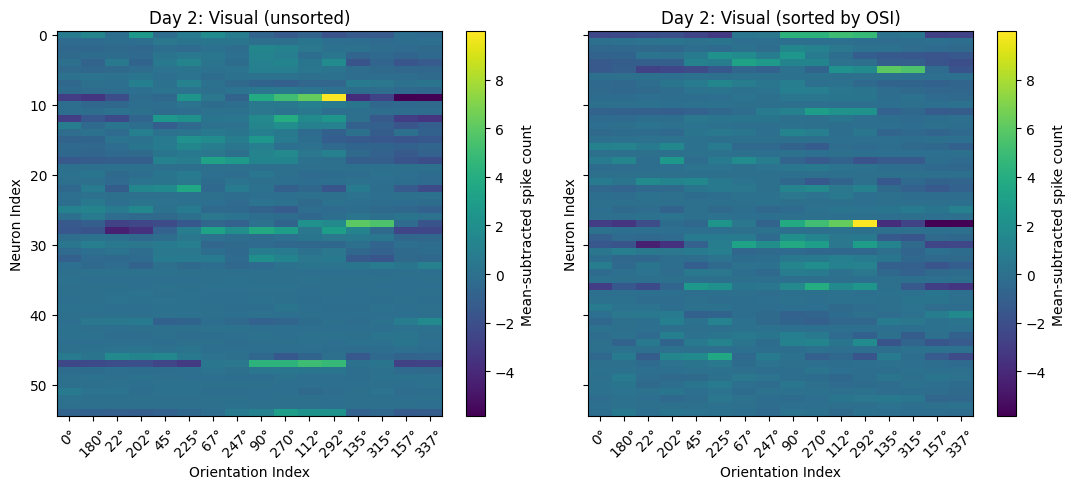

OSI range: 0.024 – 0.381  |  median: 0.104
Neuron order (high→low OSI): [47 45  2 15 18 27 36 16  5 48] ...


In [17]:
ori_order = [0, 8, 1, 9, 2, 10, 3, 11, 4, 12, 5, 13, 6, 14, 7, 15]
vis_response_2 = sum_responses_2.sum(-1)  # (n_oris, n_neurons)

# Orientation selectivity index (OSI) via circular variance on doubled angles.
# OSI = |Σ_θ r(θ) exp(2i·θ)| / Σ_θ r(θ)
# Ranges [0, 1]: 0 = untuned, 1 = perfectly selective.
thetas = np.deg2rad(visual_orientation_degs2)  # (n_oris,)
r = vis_response_2.T                           # (n_neurons, n_oris)
r_pos = np.clip(r, 0, None)                   # ensure non-negative before summing
complex_tuning = r_pos @ np.exp(2j * thetas)   # (n_neurons,)
osi = np.abs(complex_tuning) / (r_pos.sum(axis=1) + 1e-9)  # (n_neurons,)

neuron_order = np.argsort(osi)[::-1]           # descending OSI

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for ax, order, label in [
    (axes[0], np.arange(vis_response_2.shape[1]), 'unsorted'),
    (axes[1], neuron_order,                        'sorted by OSI'),
]:
    xx = vis_response_2[ori_order][:, order]
    xx = xx - xx.mean(axis=0, keepdims=True)
    im = ax.imshow(xx.T, aspect='auto', cmap='viridis')
    ax.set_ylabel('Neuron Index')
    ax.set_xlabel('Orientation Index')
    ax.set_xticks(np.arange(len(visual_orientation_degs2)))
    ax.set_xticklabels([f'{int(o)}°' for o in visual_orientation_degs2[ori_order]], rotation=45)
    ax.set_title(f'Day 2: Visual ({label})')
    plt.colorbar(im, ax=ax, label='Mean-subtracted spike count')

plt.tight_layout()
plt.show()

print(f"OSI range: {osi.min():.3f} – {osi.max():.3f}  |  median: {np.median(osi):.3f}")
print(f"Neuron order (high→low OSI): {neuron_order[:10]} ...")


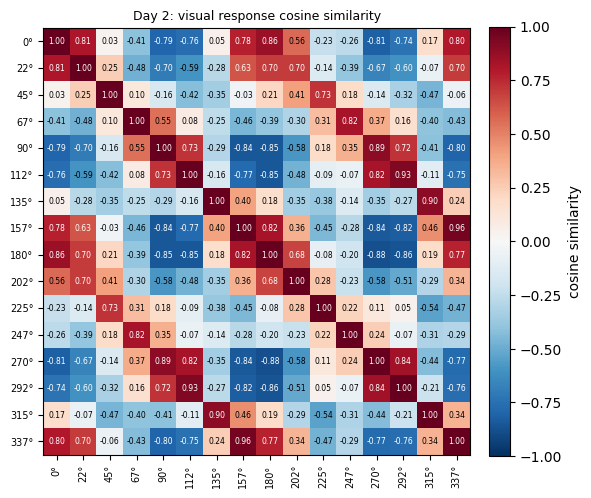

NameError: name 'build_pattern_stims_nominal' is not defined

In [18]:
# ============================================================
# Pairwise cosine similarity across the 16 orientations, for:
#   1. Visual responses          (sum_responses_2, same for all budgets/modes)
#   2. Stim patterns delivered    (per budget/mode, from pattern_df_day2)
#   3. Average electrical-stim responses (stim_resp_mean, per budget/mode)
#
# Each matrix is (n_orient x n_orient), ordered by visual_orientation_degs2.
# ============================================================
from sklearn.preprocessing import normalize


def cosine_sim_matrix(X, center=True):
    """Row-wise cosine similarity matrix for X (n_rows, n_features)."""
    Xc = X - X.mean(axis=0, keepdims=True) if center else X
    Xn = normalize(Xc, norm='l2')
    return Xn @ Xn.T


def plot_sim_matrix(ax, sim, labels, title):
    n = len(labels)
    im = ax.imshow(sim, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels([f'{int(o)}°' for o in labels], rotation=90, fontsize=7)
    ax.set_yticklabels([f'{int(o)}°' for o in labels], fontsize=7)
    ax.set_title(title, fontsize=9)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{sim[i, j]:.2f}', ha='center', va='center',
                    fontsize=5.5, color='white' if abs(sim[i, j]) > 0.6 else 'black')
    return im


# --- 1. Visual response similarity (orientation x neuron, summed over time) ---
sim_visual = cosine_sim_matrix(vis_response_2)  # (n_orient, n_orient)

fig, ax = plt.subplots(figsize=(6, 5.5))
im = plot_sim_matrix(ax, sim_visual, visual_orientation_degs2,
                      'Day 2: visual response cosine similarity')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='cosine similarity')
plt.tight_layout()
plt.show()

# --- 2 & 3. Per (budget, mode): stim pattern + avg electrical response similarity ---
channel_to_index = {ch: idx for idx, ch in enumerate(sorted(pattern_df_day2['channel'].dropna().unique()))}
pattern_stims_day2 = build_pattern_stims_nominal(
    pattern_df_day2[pattern_df_day2['pattern_name'].isin(xref['pattern_name'])],
    channel_to_index, VIS_ORIENT_TIME)

for b_idx, budget in enumerate(budgets):
    for m_idx, mode_ in enumerate(modes):
        grp = (xref[(xref['source_budget'] == budget) & (xref['decomp_method'] == mode_)]
               .sort_values('target_orientation_deg'))
        stim_flat = np.stack([pattern_stims_day2[int(p)].ravel() for p in grp['pattern_name']], axis=0)
        sim_stim = cosine_sim_matrix(stim_flat)

        resp = stim_resp_mean[b_idx, m_idx]  # (n_orient, n_neurons), already ordered by `oris`
        sim_resp = cosine_sim_matrix(resp)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
        im0 = plot_sim_matrix(axes[0], sim_stim, visual_orientation_degs2,
                               f'Stim pattern similarity\nbudget={budget} mode={mode_.upper()}')
        im1 = plot_sim_matrix(axes[1], sim_resp, visual_orientation_degs2,
                               f'Avg electrical-stim response similarity\nbudget={budget} mode={mode_.upper()}')
        plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='cosine similarity')
        plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='cosine similarity')
        plt.tight_layout()
        plt.show()
